## Verificando a versão das bibliotecas

In [1]:
!pip install scikit-optimize -q

import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import skopt
import plotly 
import numpy as np

# print(f'versão do sklearn = {sklearn.__version__}')
# print(f'versão do pandas = {pd.__version__}')
# print(f'versão do matplotlib = {plt.__version__}')
# print(f'versão do skopt = {skopt.__version__}')
# print(f'versão do plotly = {plotly.__version__}')
# print(f'versão do numpy = {np.__version__}')

## Conhecendo os dados

In [2]:
uri = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\dados_inadimplencia.csv'
dados = pd.read_csv(uri)
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [4]:
round(dados['inadimplente'].value_counts(normalize=True)*100,2)

inadimplente
0    67.65
1    32.35
Name: proportion, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

X = dados.drop(columns='inadimplente').copy()
y = dados['inadimplente'].copy()
RANDOM_STATE = 42

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

## Treinando o DecisionTreeClassifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE) # max_depth -> profundidade da árvore
model_dt.fit(X_treino, y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Avaliando o modelo

In [7]:
# Recall (taxa de verdadeiros positivos) mede a capacidade do modelo de identificar corretamente todos os casos positivos, ou seja, 
# quantos dos verdadeiros positivos ele conseguiu capturar em relação ao total de casos positivos
from sklearn.metrics import recall_score

recall_dt = recall_score(y_teste, model_dt.predict(X_teste))
print(f'Recall do DT: {recall_dt:.3f}')

Recall do DT: 0.143


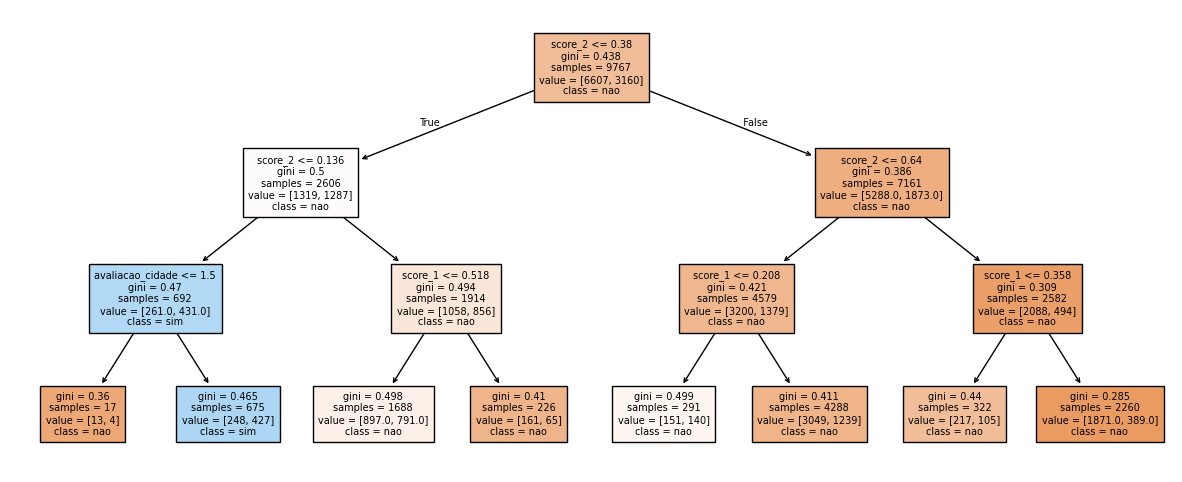

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

nome_colunas = X_treino.columns
plt.figure(figsize=(15,6))

plot_tree(model_dt, filled=True, class_names=['nao', 'sim'], fontsize=7, feature_names=nome_colunas);

## Treinando o LogisticRegression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Usado para escalas muito diferentes 

logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression())
logistic_pipeline.fit(X_treino, y_treino)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Avaliando o modelo

In [10]:
recall_lr = recall_score(y_teste, logistic_pipeline.predict(X_teste))
print(f'Recall do LR: {recall_lr:.3f}')

Recall do LR: 0.253


In [11]:
# Os coeficientes são os valores associados a cada variável de entrada na regressão logística. 
# Eles representam a contribuição de cada variável para a previsão do modelo. 
# Valores positivos indicam uma relação positiva entre a variável e a variável de destino, 
# enquanto valores negativos indicam uma relação negativa. Quanto maior o valor absoluto do coeficiente, 
# maior é a influência da variável na previsão do modelo, mas novamente nós não calculamos estes valores manualmente.
nome_colunas = list(X_treino.columns)
coef_model = logistic_pipeline.named_steps['logisticregression'].coef_[0]
coef_df = pd.DataFrame({"Coluna": nome_colunas, "coeficientes": coef_model})
coef_df.sort_values(by="coeficientes", ascending=False)

,Coluna,coeficientes
4,avaliacao_cidade,0.093488
2,anos_casa_propria,0.078257
1,anuidade_emprestimo,0.036625
0,receita_cliente,-0.012309
3,telefone_trab,-0.031449
8,score_social,-0.074919
9,troca_telefone,-0.097151
7,score_3,-0.149227
5,score_1,-0.250049
6,score_2,-0.464961


## Busca em Grade para Decision Tree Classifier

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = { 
    'criterion':  ['gini', 'entropy'],                             # Qualidade da divisão
    'max_depth': np.linspace(6, 12, 4, dtype=int),                 # Array espaçado
    'min_samples_split': np.linspace(5, 20, 4, dtype=int),         # Quantidade de mínimas amostras para divisão
    'min_samples_leaf': np.linspace(5, 20, 4, dtype=int),          # Quantidade mínimas de amostras em uma folha
    'max_features': ['sqrt', 'log2'],                              # Quantidade máxima de features
    'splitter': ['best', 'random']                                 # Medir a forma da divisão
}

In [13]:
from sklearn.model_selection import StratifiedKFold

dt_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), 
             param_grid=param_grid_dt, 
             scoring='recall', 
             n_jobs=-1, 
             cv=StratifiedKFold(shuffle=True, random_state=RANDOM_STATE), 
             )

dt_grid_search.fit(X_treino, y_treino)



,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': array([ 6, 8, 10, 12]), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([ 5, 10, 15, 20]), ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


## Obtendo informações da busca em grade

In [14]:
dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [15]:
df_cv_results_dt = pd.DataFrame(dt_grid_search.cv_results_)
df_cv_results_dt.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011331,0.001109,0.005440,0.000271,gini,6,sqrt,5,5,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251
1,0.005744,0.000631,0.004480,0.000326,gini,6,sqrt,5,5,random,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.193038,0.132911,0.132911,0.112342,0.161392,0.146519,0.028013,493
2,0.011292,0.002226,0.004709,0.000822,gini,6,sqrt,5,10,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251


In [16]:
df_cv_results_dt.loc[[dt_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.01634,0.000997,0.004718,0.000629,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


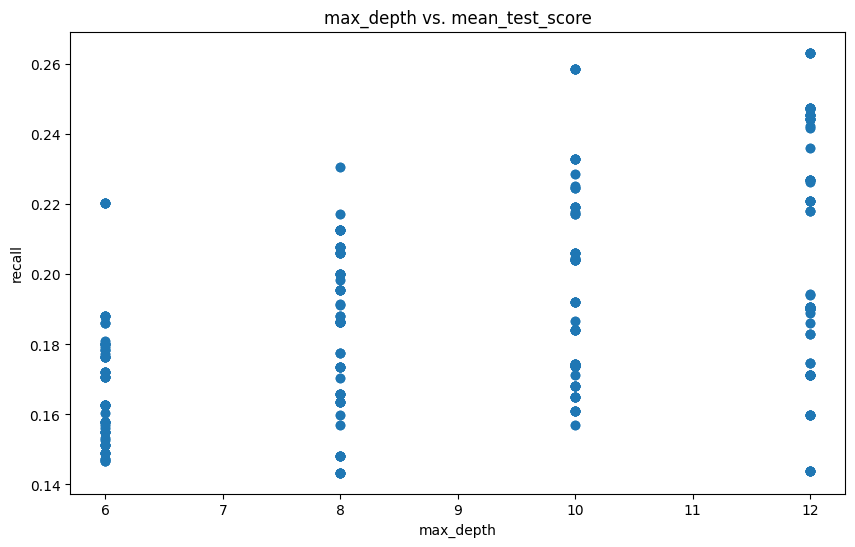

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(df_cv_results_dt['param_max_depth'], df_cv_results_dt['mean_test_score'])
plt.title('max_depth vs. mean_test_score')
plt.xlabel('max_depth')
plt.ylabel('recall')
plt.show()

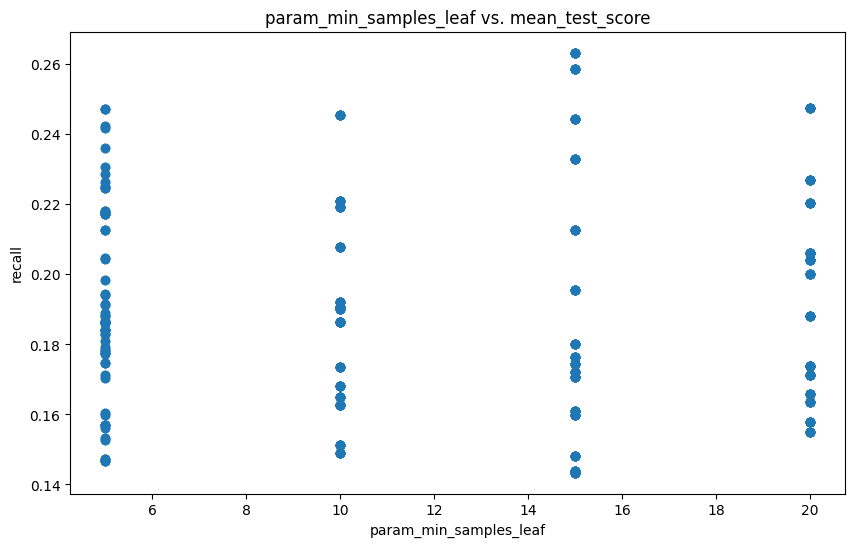

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df_cv_results_dt['param_min_samples_leaf'], df_cv_results_dt['mean_test_score'])
plt.title('param_min_samples_leaf vs. mean_test_score')
plt.xlabel('param_min_samples_leaf')
plt.ylabel('recall')
plt.show()

## Busca em grade para o LogisticRegression

In [19]:
max_iter = np.linspace(100, 300, 5, dtype=int)
c = [0.001, 0.01, 0.1, 1, 10]

param_grid_lr = [
    {'logisticregression__solver' : ['newton-cg', 'lbfgs'],
      'logisticregression__penalty' : ['l2'],
      'logisticregression__max_iter' : max_iter,
       'logisticregression__C' : c},
    {'logisticregression__solver' : ['liblinear'],
      'logisticregression__penalty' : ['l1', 'l2'],
      'logisticregression__max_iter' : max_iter,
      'logisticregression__C' : c},
]

lr_grid_search = GridSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression()), 
             param_grid=param_grid_lr, 
             scoring='recall', 
             n_jobs=-1, 
             cv=StratifiedKFold(shuffle=True, random_state=RANDOM_STATE), 
             )

lr_grid_search.fit(X_treino, y_treino)


,estimator,Pipeline(step...egression())])
,param_grid,"[{'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__max_iter': array([100, 1...00, 250, 300]), 'logisticregression__penalty': ['l2'], 'logisticregression__solver': ['newton-cg', 'lbfgs']}, {'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__max_iter': array([100, 1...00, 250, 300]), 'logisticregression__penalty': ['l1', 'l2'], 'logisticregression__solver': ['liblinear']}]"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### Melhores parâmetros

In [20]:
lr_grid_search.best_params_

{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [22]:
df_cv_results_lr = pd.DataFrame(lr_grid_search.cv_results_)
df_cv_results_lr.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015254,0.000321,0.005181,0.000542,0.001,100,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86
1,0.009518,0.000948,0.004342,0.000654,0.001,100,l2,lbfgs,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.113924,0.087025,0.079114,0.096835,0.012313,91
2,0.013354,0.001008,0.005873,0.000652,0.001,150,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86


In [23]:
df_cv_results_lr.loc[[lr_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
51,0.014253,0.003197,0.005797,0.000304,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


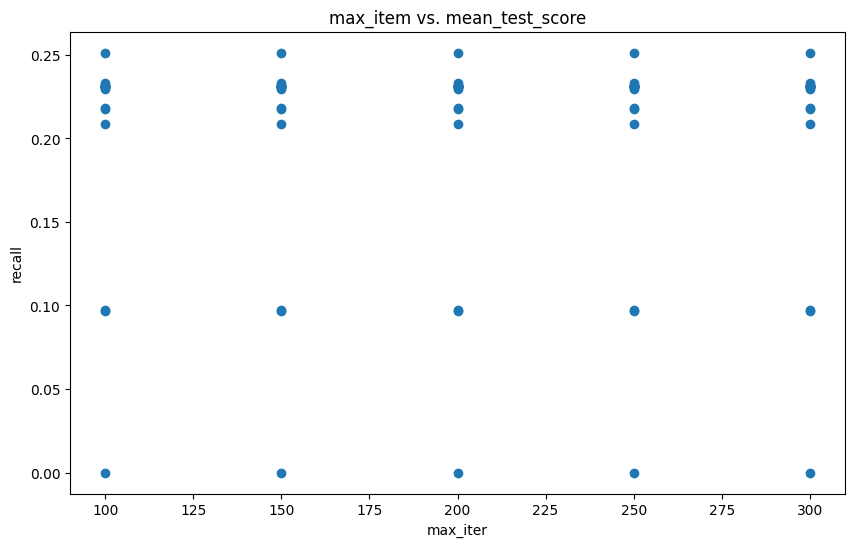

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(df_cv_results_lr['param_logisticregression__max_iter'], df_cv_results_lr['mean_test_score'])
plt.title('max_item vs. mean_test_score')
plt.xlabel('max_iter')
plt.ylabel('recall')
plt.show()

## Desafio da Aula

In [25]:
# O KNN é um método intuitivo e muito utilizado em tarefas de classificação e regressão. 
# Ele faz previsões para uma nova amostra baseando-se nas K amostras mais próximas do conjunto de dados de treino, 
# utilizando uma métrica de distância, como por exemplo a euclidiana. Em contextos de classificação, 
# a categoria mais frequente entre os K vizinhos é usada como previsão. 
# Sendo um algoritmo não-paramétrico e baseado em instâncias, o KNN não pressupõe uma distribuição específica dos dados, 
# confiando diretamente nos dados de treino para prever resultados.
from sklearn.neighbors import KNeighborsClassifier
from numpy import linspace
from sklearn.pipeline import Pipeline

param_grid_knn = {
    'knn__n_neighbors': linspace(5, 25, 10, dtype=int),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid_search = GridSearchCV(estimator = pipe_knn,
                               param_grid = param_grid_knn,
                               scoring = "recall",
                               n_jobs = -1,
                               cv = cv)

knn_grid_search.fit(X_treino, y_treino)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': array([ 5, 7..., 20, 22, 25]), 'knn__weights': ['uniform', 'distance']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [26]:
knn_grid_search.best_params_

{'knn__metric': 'manhattan',
 'knn__n_neighbors': np.int64(5),
 'knn__weights': 'distance'}

In [28]:
df_cv_results_knn = pd.DataFrame(knn_grid_search.cv_results_)
df_cv_results_knn.loc[[knn_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__metric,param_knn__n_neighbors,param_knn__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
21,0.018423,0.001608,0.347423,0.019694,manhattan,5,distance,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.375,0.370253,0.373418,0.356013,0.357595,0.366456,0.008043,1
